<h1 style="text-align:center"> Assignmnent 2 [Eric Kamalendran] [250733547]</h1>

Assignment 2 is the coursework 2 for our module ECS7039P, which carries 60% of your grades for this module. In this assignment, you will be asked to download a dataset from github and analyse it. ***Everything in this assignment is to be done in Python***. 

Similar to assignment  1, you will be asked to explain your code, approach, and results. Unlike assignment 1, many of questions in assignment 2 are open-ended questions, where analysis steps depend on you and how well you understand the problem.

All the Best!<br>Fabricio Ourique


<br>

<div style="padding: 10px; border: 2px solid green;background-color: rgba(200,200,200,0.2);">
This Assignment will be evaluated based on:

* (1) Correctness of code for the given task (i.e., If your code is performing the task correctly)
* (2) Explanation of the logical flow of your code and the results you produced for the task, inclusing Docstring of the fuctions.

Marks for each section and subsections are indicated in the square brackets, such as [2 Marks]

</div>

<br>

<div style="padding: 10px; border: 4px solid red;">
Update your name and QMUL student ID on the top heading, by double clicking it.
</div>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import glob, pickle, os
import IPython

<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 1. Download data and setup

<!-- <center><font size="5">MLEnd Spoken Numerals Dataset</font></center> -->
<font size="5">MLEnd Spoken Numerals Dataset</font>

**MLEnd Spoken Numerals Dataset** is an open dataset, publicly shared on github. The details about the dataset can be found here: https://MLEndDatasets.github.io/spoken_numerals/. Go to this link and read about the dataset carefully to understand the kind of dataset you will be dealing with.
<br>
<center>
<img src="./images/dataset-cover.jpeg" alt="MLEnd Spoken Numerals Dataset" width=40%/>
<br>
Figure 1: MLEnd Spoken Numerals Dataset  - <a href="https://MLEndDatasets.github.io">https://MLEndDatasets.github.io</a></center>

<div style="padding: 10px; border: 1px solid lightblue;">

<center>
 <span style="align:center; color:blue"> <font size="5">Tip: More you know about your dataset, the better would be your analysis.</font></span>
</center>
</div>

The full dataset can be downloaded in three ways **choose any ONE** of the following options
- **1.1 Using MLEDN python library**  - this might take a long time or might not work due to restrictions, try other options
- **1.2 Download manually (from Github)**
- **1.3 From shared data or link**

After downloading make sure to test if you have all the required dataset by running test blocks in 1.4 section.

### 1.1 Using MLEnd python library

Run the following commands

In [2]:
try:
    import mlend
    print('='*50)
    print("MLEnd library is already installed and imported")
    print('='*50)
except:
    print("MLEnd library is not installed. Let's install it (need internet connected).")
    os.system("pip install mlend")
    import mlend
    print('='*50)
    print("MLEnd library is now already installed and imported")
    print('='*50)

MLEnd library is already installed and imported


In [3]:
import mlend
from mlend import download_spoken_numerals, spoken_numerals_load

save_to = './data/'

subset = {}
datadir = download_spoken_numerals(save_to = save_to, 
                                   subset = subset,verbose=1,overwrite=False)

  0%|                                                  |32654\208|00316.wav

KeyboardInterrupt: 

In [ ]:
print(f'You data is in directory - {datadir}')

### 1.2 Dowload manually (from Github)

In case, using ```mlend``` library (as explained above in 1.1 section) doesn't work, due to restrictions on download from github, you could download the dataset manually from github link - https://github.com/MLEndDatasets/SpokenNumerals. Go to link and download manually as shown in figure below.

<center>
<img src="./images/download_from_github.png" alt="Download from gith" width=70%/>
<br>
Figure 2: Download dataset from github  - <a href="https://github.com/MLEndDatasets/SpokenNumerals">https://github.com/MLEndDatasets/SpokenNumerals</a>. Click on "Download Zip"</center>
<br>

**IMPORTANT: Store and extract the Downloaded Zip ('SpokenNumerals-main.zip') in ./data folder.**

In this case, your ```datadir``` will be different than section 1.1. It should be as follow:

```python

datadir = './data/SpokenNumerals-main'

```


In [5]:
datadir = './data/SpokenNumerals-main'

### 1.3 From shared data or link

You could also take the full dataset from someone, who has already downloaded it. Make sure to take the entire dataset and keep it in the data folder.


**IMPORTANT: Store and extract the Downloaded Zip taken from someone ('SpokenNumerals-main.zip') in ./data folder.**

In this case, your ```datadir``` will be different than section 1.1. It should be as follow:

```python

datadir = './data/SpokenNumerals-main'

```

In [6]:
datadir = './data/SpokenNumerals-main'

### 1.4 Test downloaded dataset: 


After you download the dataset, we have to make sure you have all the files is the dataset are in correct location and format.

To test the dataset, run the following code blocks, and if you see no errors, you are good to go to the next sections.

Run the following piece of code to test if you have downloaded and stored data correctly. 

Finally, you should have one directory named - `MLEndSND_audiofiles` with 32716 wave files, and at least two CSV files named as `MLEndSND_audio_attributes_benchmark.csv` and `MLEndSND_speakers_demographics_benchmark.csv`

Your file structure should be like as shown below

```python

./data/SpokenNumerals-main

  |- MLEndSND_audiofiles
  |   |- 00000.wav
  |   |- 00001.wav
  |   |   .
  |   |   .
  |
  |- MLEndSND_audio_attributes_benchmark.csv
  |- MLEndSND_speakers_demographics_benchmark.csv

```

#### Test 1 

In [19]:
# Make sure All the required files are in datadir

audio_attribute_file = 'MLEndSND_audio_attributes_benchmark.csv'
speaker_demographic_file = 'MLEndSND_speakers_demographics_benchmark.csv'


CSVFiles = glob.glob(datadir + '/*.csv')
WAVFiles = glob.glob(datadir + '/MLEndSND_audiofiles/*.wav')


assert datadir+'/'+ audio_attribute_file in CSVFiles
assert datadir+'/'+ speaker_demographic_file in CSVFiles
assert len(WAVFiles)==32716

#### Test 2

sampling rate = 22050  shape of x = (33024,)


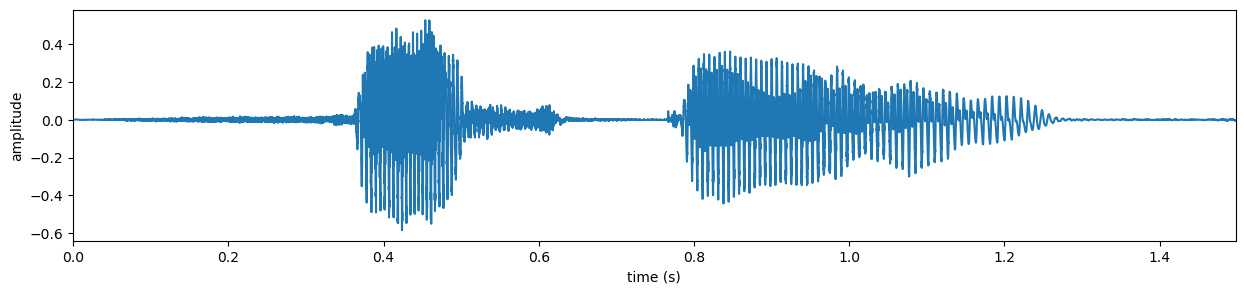

In [22]:
# Test one audio file

fs, x = scipy.io.wavfile.read(datadir + '/MLEndSND_audiofiles/00003.wav')

print('sampling rate =',fs, ' shape of x =', x.shape)

t = np.arange(len(x))/fs
x = x/(2**15)

plt.figure(figsize=(15,3))
plt.plot(t,x)
plt.xlim([t[0],t[-1]])
plt.xlabel('time (s)')
plt.ylabel('amplitude') 
plt.show()

IPython.display.Audio(x,rate=fs)

<div style="padding: 10px; border: 1px solid green;">

<center>
 <span style="align:center; color:green"> <font size="5"> If you could run the above cell without error, you will see figure of a waveform and an audio player that will produce a sound of word 'fifteen', you are all set-up to go furthur</font></span>
</center>
</div>

If you face error, make sure you have downloaded entire dataset from given link, extracted the compressed folder and renamed folder name to 'data' and keep it in your current folder.

<br>
<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

In [ ]:
glob.glob(datadir + '/*')

### 1.5 Notes on Dataset:

File `MLEndSND_audio_attributes_benchmark.csv`, `MLEndSND_speakers_demographics_benchmark.csv`, and audio file names in `MLEndSND_audiofiles` folder are linked.


* `MLEndSND_audio_attributes_benchmark.csv` file contains attributes of each audio file. So, there should be the same number of rows in `MLEndSND_audio_attributes_benchmark.csv` file as a number of audio files in `MLEndSND_audiofiles` folder.

* In `MLEndSND_audio_attributes_benchmark.csv` file, column named  - 'filename' refers to audio file name in `MLEndSND_audiofiles` folder. Audio file name is a five digit number followed by .wav extension. For example, a wave-file with has filename as  '00007.wav' should have a full path as  filepath = datadir + '/MLEndSND_audiofiles' + filename

* In `MLEndSND_audio_attributes_benchmark.csv` file, column named  - 'Speaker' refer to speaker, which is same as in `MLEndSND_speakers_demographics_benchmark.csv` file.

Example:
  In `MLEndSND_audio_attributes_benchmark.csv` file, third row is

<br>
<center>
<table>
  <tr>
    <th>|</th>
    <th>filename</th>
    <th>Numeral</th>
    <th>Intonation</th>
    <th>Speaker</th>
    <th>Benchmark_A</th>
    <th>Benchmark_B</th>
  </tr>
  <tr>
    <td></td>
    <td>00003.wav</td>
    <td>15</td>
    <td>excited</td>
    <td>107</td>
    <td>Train</td>
    <td>Train</td>
  </tr>
</table>
</center>
  
    
that means, audio file name `00003.wav` has a sound of Numeral '15' spoken by speaker number '107', in 'excited' mood (intonation). 
 
if we look for details of speaker 107 in `MLEndSND_speakers_demographics_benchmark.csv`  file, we will find
 
  <br>
<center>
  <table>
  <tr>
    <th>|</th>
    <th>Speaker</th>
    <th>Language1</th>
    <th>Language2</th>
    <th>Nationality</th>
    <th>Coordinates</th>
    <th>Benchmark_A</th>
  </tr>
  <tr>
    <td></td>
    <td>107</td>
    <td>Bravanese</td>
    <td>English</td>
    <td>British</td>
    <td>(51.57, -0.07)</td>
    <td>Train</td>
  </tr>
</table>
</center>


 that means speaker 107 has British nationality, with first language as Bravanese and second language as English.



For this module and assignment, we will ignore the Benchmark columns in both files. 
  
***It is recommended that you read the dataset description carefully from the given link.***

<div style="padding: 10px; border: 1px solid green;">

<center>
 <span style="align:center; color:green"> <font size="5">Your assignment work, which will be evaluated starts from here onwards</font></span>
</center>
</div>

## 2. Read files and summarise the data [3 Marks]

After downloading dataset, you should have all the audio files in `MLEndSND_audiofiles` folder and two CSV files explaining the attributes of audio files and speakers. 

Two CSV files in dataset are
 - `MLEndSND_speakers_demographics_benchmark.csv` and
 - `MLEndSND_audio_attributes_benchmark.csv`

<br>

<div style="padding: 10px; border: 4px dashed black;">

**Q2.1:**
    
* Create a list of all audio files as their full path (use ```file_list = glob.glob(path)```). 
* Read both CSV files (as listed above) and summarise the dataset.

    Summarising the dataset here means tabulating the number of audio files you have in the dataset for different speakers, numerals, nationalities and intonations. You could add an additional summary about the dataset too.
    
    
    * **Create tables and write your explanations in a given box**.
    
    
</div>

In [71]:
import glob
import pandas as pd
import os


# 0. Base path

base_path = "data/SpokenNumerals-main"


# 1. Load audio file paths

audio_path = f"{base_path}/MLEndSND_audiofiles/**/*.wav"
file_list = glob.glob(audio_path, recursive=True)

print("Total number of audio files:", len(file_list))
print("Sample files:", file_list[:5])


# 2. Load files

speakers_csv = f"{base_path}/MLEndSND_speakers_demographics_benchmark.csv"
audio_csv = f"{base_path}/MLEndSND_audio_attributes_benchmark.csv"

speakers_df = pd.read_csv(speakers_csv)
audio_df = pd.read_csv(audio_csv)

print("\n Column Names ")
print("Audio columns:", list(audio_df.columns))
print("Speaker columns:", list(speakers_df.columns))


# 3. Merge 

common_cols = list(set(audio_df.columns).intersection(set(speakers_df.columns)))

if len(common_cols) == 0:
    raise ValueError("No common column found to merge on. Check dataset.")
    
merge_col = common_cols[0]  
print(f"\nMerging on column: {merge_col}")

merged_df = pd.merge(audio_df, speakers_df, on=merge_col)

print("\nMerged DataFrame preview:")
print(merged_df.head())


# 4. Summary Tables 

def safe_groupby(df, column_name):
    if column_name in df.columns:
        return df.groupby(column_name).size().reset_index(name="count")
    else:
        print(f"Warning: '{column_name}' not found.")
        return None

files_per_speaker = safe_groupby(merged_df, merge_col)
files_per_numeral = safe_groupby(merged_df, "numeral")
files_per_nationality = safe_groupby(merged_df, "nationality")
files_per_intonation = safe_groupby(merged_df, "intonation")
files_per_gender = safe_groupby(merged_df, "gender")


# 5. Print Results

def print_table(title, df):
    if df is not None:
        print(f"\n{title} ")
        print(df.to_string(index=False))

print_table("Files per Speaker", files_per_speaker)
print_table("Files per Numeral", files_per_numeral)
print_table("Files per Nationality", files_per_nationality)
print_table("Files per Intonation", files_per_intonation)
print_table("Files per Gender", files_per_gender)


# 6. Summary

print("\n Additional Summary ")
print("Total Speakers:", merged_df[merge_col].nunique())

if files_per_speaker is not None:
    print("Average files per speaker:", round(files_per_speaker["count"].mean(), 2))

if "numeral" in merged_df.columns:
    print("Unique numerals:", merged_df["numeral"].nunique())

if "nationality" in merged_df.columns:
    print("Unique nationalities:", merged_df["nationality"].nunique())

if "intonation" in merged_df.columns:
    print("Unique intonations:", merged_df["intonation"].nunique())
    

Total number of audio files: 32716
Sample files: ['data/SpokenNumerals-main/MLEndSND_audiofiles/34900.wav', 'data/SpokenNumerals-main/MLEndSND_audiofiles/30752.wav', 'data/SpokenNumerals-main/MLEndSND_audiofiles/09899.wav', 'data/SpokenNumerals-main/MLEndSND_audiofiles/40351.wav', 'data/SpokenNumerals-main/MLEndSND_audiofiles/43112.wav']

 Column Names 
Audio columns: ['filename', 'Numeral', 'Intonation', 'Speaker', 'Benchmark_A', 'Benchmark_B']
Speaker columns: ['Speaker', 'Language1', 'Language2', 'Nationality', 'Coordinates', 'Benchmark_A']

Merging on column: Speaker

Merged DataFrame preview:
    filename  Numeral Intonation  Speaker Benchmark_A_x Benchmark_B  \
0  00000.wav        3    excited       59         Train        Test   
1  00001.wav  1000000   question       31         Train        Test   
2  00003.wav       15    excited      107         Train       Train   
3  00004.wav       13    excited      114         Train        Test   
4  00005.wav       19    neutral      13


<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 3. Select data of your assigned speaker and summarise [3 Marks]

Out of 32654 audio files, you will be working on audio files of only one speaker. Your speaker is the last two digits of your QMUL Student ID.

If your ID is 260056649 your speaker is 49

Your assigned speaker number is 49, change the value of My_speaker as follows:

```python

My_speaker = 47

```
<br>

<div style="padding: 10px; border: 4px dashed black;">

* **Q3.1:** Extract the attributes of audio files from `MLEndSND_audio_attributes_benchmark.csv` which belong to your assigned speaker and summarise the data in a similar fashion as Q2.1.

</div>

In [70]:
#Q3.1

My_speaker = 47

import pandas as pd
import glob

 
# 0. speaker number
 
My_speaker = 47

 
# 1. Load dataset
 
base_path = "data/SpokenNumerals-main"

audio_csv = f"{base_path}/MLEndSND_audio_attributes_benchmark.csv"
audio_df = pd.read_csv(audio_csv)


# 2. Check columns 

print("Columns:", list(audio_df.columns))


# 3. Filter data for ONE speaker
# Try common column names automatically
speaker_col = None

for col in audio_df.columns:
    if "speaker" in col.lower():
        speaker_col = col
        break

if speaker_col is None:
    raise ValueError("No speaker column found!")

print("Using speaker column:", speaker_col)

speaker_df = audio_df[audio_df[speaker_col] == My_speaker]

print("\nTotal files for this speaker:", len(speaker_df))
print(speaker_df.head())


# 4. Summary tables

def safe_groupby(df, column_name):
    if column_name in df.columns:
        return df.groupby(column_name).size().reset_index(name="count")
    else:
        print(f"Column '{column_name}' not found")
        return None

files_per_numeral = safe_groupby(speaker_df, "numeral")
files_per_intonation = safe_groupby(speaker_df, "intonation")


# 5. Print results

def print_table(title, df):
    if df is not None:
        print(f"\n {title} ")
        print(df.to_string(index=False))

print_table("Files per Numeral (Speaker 49)", files_per_numeral)
print_table("Files per Intonation (Speaker 49)", files_per_intonation)


# 6. Additional summary

print("\n Additional Summary ")
print("Total recordings for speaker:", len(speaker_df))

if "numeral" in speaker_df.columns:
    print("Unique numerals:", speaker_df["numeral"].nunique())

if "intonation" in speaker_df.columns:
    print("Unique intonations:", speaker_df["intonation"].nunique())





Columns: ['filename', 'Numeral', 'Intonation', 'Speaker', 'Benchmark_A', 'Benchmark_B']
Using speaker column: Speaker

Total files for this speaker: 206
      filename  Numeral Intonation  Speaker Benchmark_A Benchmark_B
24   00037.wav       10   question       47       Train       Train
240  00359.wav        6    excited       47       Train        Test
253  00377.wav        8    neutral       47       Train       Train
558  00824.wav       60    excited       47       Train       Train
568  00837.wav       15    neutral       47       Train       Train
Column 'numeral' not found
Column 'intonation' not found

 Additional Summary 
Total recordings for speaker: 206


<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 4. Compute features of audio files of your selected speaker [27 Marks]

### 4.1 Read and clean audio files [2 Mark]

<div style="padding: 10px; border: 4px dashed black;">
    
**Q4.1A:** Create a function that takes a filename (as it is in `MLEndSND_audio_attributes_benchmark.csv`), reads the respective audio file and returns sampling rate `fs` and audio samples as `x`.

Example: if filename is 00003.wave, then path of audio file is 
             path = datadir + '/MLEndSND_Public/00003.wav'


Process your audio samples x with the following cleaning steps:

* Divide x with 2^15 to covert integer type to float values of x (check section 1.1 test function)

* Some of the audio files will have 2-channel recording, which will return an array of many rows and 2 columns. Each column is one channel. If an audio file you are reading has 2-channels, select the first column only and return x. 
    


**An empty code function is given in cell below.**
    
</div>

In [7]:
#Complete the code for following two functions as described above.

#Q4.1a

import numpy as py
from scipy.io import wavfile
import os

datadir = "data/SpokenNumerals-main"

def load_audio(filename):
    # 1. full path
    path = os.path.join(datadir, "MLEndSND_audiofiles", filename)

    # 2. Read audio file
    fs, x = wavfile.read(path)

    # 3. Convert to float
    x = x / (2**15)

    # 4. Handle stereo (2-channel)
    if len(x.shape) > 1:
        x = x[:, 0]

    return fs, x


# Test
fs, x = load_audio("00003.wav")
print(fs, len(x))


22050 33024


#### 4.1 Tests


Run following cell to test, whether your implementation of functions above is correct.

In [ ]:
freez this  nikb

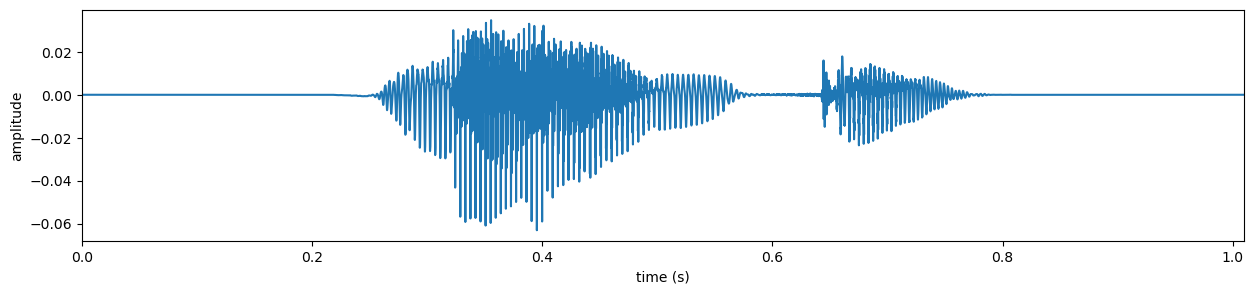

In [79]:
# Tests

from IPython.display import Audio

fs, x = read_audio_file(filename = '06801.wav')

assert x.ndim==1           
assert x.dtype==float        
assert np.max(np.abs(x))<=1  


t = np.arange(len(x))/fs
plt.figure(figsize=(15,3))
plt.plot(t,x)
plt.xlim([t[0],t[-1]])
plt.xlabel('time (s)')
plt.ylabel('amplitude') 
plt.show()

display(Audio(x, rate=fs))

<div style="padding: 3px; border: 2px solid green;">

<center>
 <span style="align:center; color:green"> <font size="3"> If you could run the above cell without error, your implementations of functions are correct.</font></span>
</center>
</div>

<br>

<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

### 4.2 Extract silence and non-silence part of audio [9 Marks]

Before analysing audio files, you will need to extract the silence and non-silence parts. In this part of the section, you have to write a function that extracts the segments of silence and non-silence parts of the given audio file. 

<br> 

<div style="padding: 10px; border: 4px dashed black;">
    
**Q4.2A:** **Design your own approach** to extract the silence and non-silence parts of audio recording. Write a function that takes sample array x, and sampling rate fs and returns the silence and non-silence parts of audio.

You need to explain your approach and logic to extract the silence and non-silence parts. **DO NOT** use any signal processing libraries that extract the silence and non-silence parts of audio automatically, otherwise the marks for this part of the assignment will be **ZERO**.
    
</div>


#### Explanation - Silence/Non-silence parts

If you observe the recording waveforms by listening to it or plotting it, you will notice some parts of it where speaker is silent (not speaking anything). That part of audio is called as silence parts and rest is called non-silence part. An example of audio file is shown below (Figure 3), where silent parts of the audio are where the amplitude of samples (intensity) is very low.

<img src="./images/audio_silence_non_silence.png" alt="Silence and Non-silence parts of audio" width=100%/>
<br>
<center>Figure 3: Silence and Non-silence parts of audio file</center>


You are encouraged to explore the idea and theory behind it and create your own logic. It might not be perfect, but that is okay. To test your function, try several audio files from the dataset. Plot them by highlighting the silence and non-silence part.

**An example of plotting vertical lines on a waveform to show silence and non-silence parts is here.**

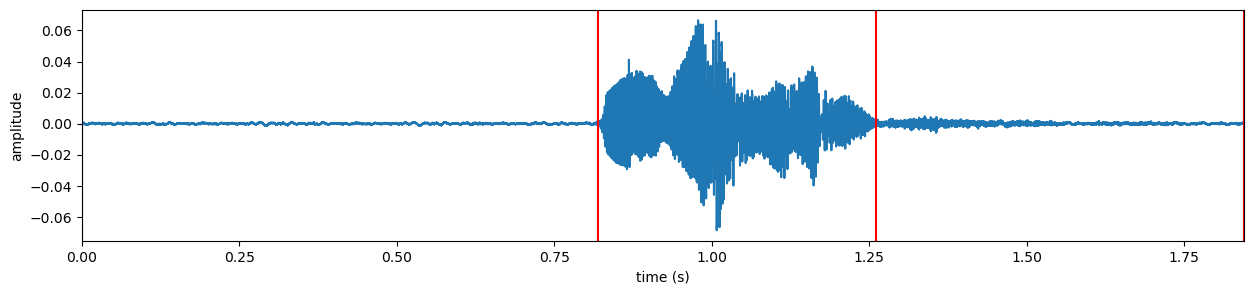

In [23]:
fs, x = scipy.io.wavfile.read(datadir + '/MLEndSND_audiofiles/00001.wav')
t = np.arange(len(x))/fs
x = x/(2**15)

# indexes of silience parts

silence_idx1_start = 0
silence_idx1_end   = 18083

silence_idx2_start = 27798
silence_idx2_end = len(x)-1


plt.figure(figsize=(15,3))
plt.plot(t,x)
plt.xlim([t[0],t[-1]])
plt.xlabel('time (s)')
plt.ylabel('amplitude')
plt.axvline(t[silence_idx1_start],color='r')
plt.axvline(t[silence_idx1_end],color='r')

plt.axvline(t[silence_idx2_start],color='r')
plt.axvline(t[silence_idx2_end],color='r')
plt.show()

#### Your solution: code and explanation 

Total samples: 40704
Silence samples: 38414
Non-silence samples: 2290


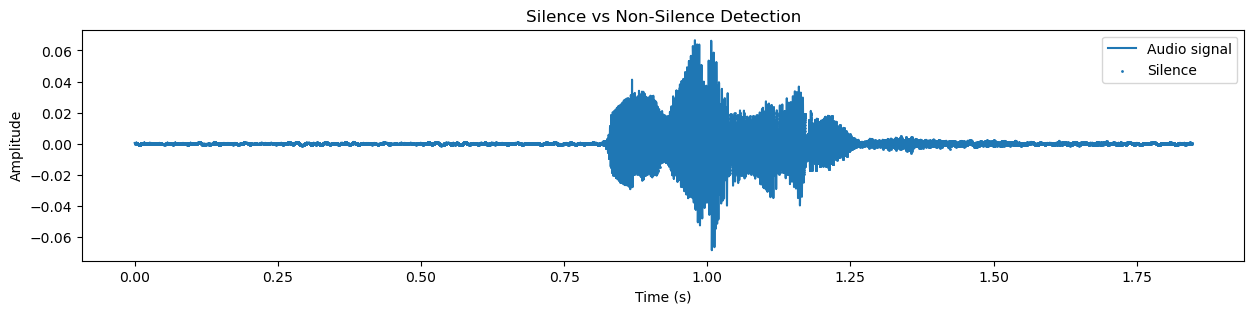

In [13]:
#Q4.2A

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os


# 0. Base directory

datadir = "data/SpokenNumerals-main"


# 1. Load audio 

def load_audio(filename):
    path = os.path.join(datadir, "MLEndSND_audiofiles", filename)
    
    fs, x = wavfile.read(path)
    
    # convert to float
    x = x / (2**15)
    
    # handle stereo
    if len(x.shape) > 1:
        x = x[:, 0]
    
    return fs, x


# 2. Silence detection function

def detect_silence(x, fs, threshold=0.02):
    # absolute signal
    x_abs = np.abs(x)
    
    # silence and non-silence indices
    silence_idx = np.where(x_abs < threshold)[0]
    nonsilence_idx = np.where(x_abs >= threshold)[0]
    
    return silence_idx, nonsilence_idx


# 3. example file

filename = "00001.wav"

fs, x = load_audio(filename)

silence_idx, nonsilence_idx = detect_silence(x, fs)

print("Total samples:", len(x))
print("Silence samples:", len(silence_idx))
print("Non-silence samples:", len(nonsilence_idx))


# 4. Plot waveform + silence

t = np.arange(len(x)) / fs

plt.figure(figsize=(15,3))
plt.plot(t, x, label="Audio signal")

# highlight silence (red dots)
plt.scatter(t[silence_idx], x[silence_idx], s=1, label="Silence")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Silence vs Non-Silence Detection")
plt.legend()
plt.show()



### 4.3 Compute features of audio file [16 Marks]

<div style="padding: 10px; border: 4px dashed black;">

**Q4.3**: For given array of sample values from audio file as x, and sampling rate as fs, write the code for following functions.

* **Q4.3A:** Function to compute the duration of silence and duration of non-silence part of audio file. [4 MARKS]
* **Q4.3B:** Function to compute the energy of silence and non-silence part of audio file. [4 MARKS]
* **Q4.3C:** Function to compute the mean and standard deviation of                        [4 MARKS]
  * positive values of samples in array x.
  * negative values of samples in array x.
* **Q4.3D:** Function to compute zero-crossing rate of silence and non-silence part of audio file. [4 MARKS]
    
    
**For each, DO write the proper docstring, explaining your approach, input and output of the function.**
    
</div>

After completing above five functions, you will have total 10 features for an audio file, which are tabulated below.

<center>
    <caption><b>Table 1: List of features</b></caption>
<table>
  <tr>
    <th>SN</th>
    <th>Feature</th>
    <th></th>
  </tr>
  <tr>
    <td>1</td>
    <td>Duration of silence part</td>
    <td></td>
  </tr>
  <tr>
    <td>2</td>
    <td>Energy of silence part</td>
    <td></td>
  </tr>
    <tr>
    <td>3</td>
    <td>Zero-crossing of silence part</td>
    <td></td>
  </tr>
  <tr>
    <td>4</td>
    <td>Duration of non-silence part</td>
    <td></td>
  </tr>
  <tr>
    <td>5</td>
    <td>Energy of non-silence part</td>
    <td></td>
  </tr>
   <tr>
    <td>6</td>
    <td>Zero-crossing of non-silence part</td>
    <td></td>
  </tr>
     <tr>
    <td>7</td>
    <td>Mean of positive values of x</td>
    <td></td>
  </tr>
       <tr>
    <td>8</td>
    <td>Standard Deviation of positive values of x</td>
    <td></td>
  </tr>
       <tr>
    <td>9</td>
    <td>Mean of negative values of x</td>
    <td></td>
  </tr>
       <tr>
    <td>10</td>
    <td>Standard Deviation  of negative values of x</td>
    <td></td>
  </tr>
</table>  
</center>

#### Explanation of audio features

Some of the audio features in questions are explained here.

#### Duration of audio file:

Duration of audio file in seconds can be computed by using the sampling rate (fs). Sampling rate, fs, tells us how many samples were recorded in one second. For example, if the sampling rate is 100, and we have 1000 sample values in x array, then following the logic, we could compute that the duration of this audio file us 1000/100 =  10 seconds. 


#### Energy of audio signal:

The energy of an audio signal, or energy of a signal in general is computed as follows. 


$$E_x = \sum_{i=0}^{N-1} x(i)^2$$


which means, a sum of squared values of x.



#### Zero-crossing rate:

Zero-crossing rate is a common attribute computed for a signal, especially for sound and audio signals. It  is computed as how many times the signal crosses the zero-line divided by the length of signal. In other words, how many times, the amplitude of signal go from + (positive values) to - (negative values) or - (negative values) to + (positive values).

Example:

if a signal $x = [0.1, 0.3, -0.1, -0.3, 0.1, 0.5, 0.8. -0.5]$, then we can see, signal x cross zero line 3 times:

    * First, from 0.3 to -0.1, 
    * Second, from -0.3 to 0.1, and
    * Third, from 0.8 to -0.5
    
Since, length of x in this example is 8, zero-crossing rate of x is 3/8 = 0.375

#### Your solution:  functions and explanations

In [2]:
#Q4.3A Duration

import numpy as np
import os
from scipy.io import wavfile

#load audio

datadir = "data/SpokenNumerals-main"

def load_audio(filename):
    path = os.path.join(datadir, "MLEndSND_audiofiles", filename)
    fs, x = wavfile.read(path)

    x = x / (2**15)

    if len(x.shape) > 1:
        x = x[:, 0]

    return fs, x

    
def duration(x, fs, silence_idx, nonsilence_idx): 
    """
    Compute duration of silence and non-silence parts of audio.

    Parameters:

    x (array): audio signal 
    fs (int): sampling rate (samples per second)
    silence_idx (array): indices of silence samples
    nonsilence_idx (array): indices of non-silence samples 

      Returns:
        silence_dur (float): duration of silence in seconds
        nonsilence_dur (float): duration of non-silence in seconds
    """

    silence_dur = len(silence_idx) / fs
    nonsilence_dur = len(nonsilence_idx) / fs
    return silence_dur, nonsilence_dur






In [7]:
#Q4.3B Energy

import numpy as np

def energy(x, silence_idx, nonsilence_idx):
    """
    Compute energy of silence and non-silence parts.

    Energy is defined as sum of squared signal values.

    Parameters:
        x (array): audio signal
        silence_idx (array): indices of silence samples
        nonsilence_idx (array): indices of non-silence samples

    Returns:
        silence_energy (float): energy of silence part
        nonsilence_energy (float): energy of non-silence part
    """
    
    silence_energy = np.sum(x[silence_idx]**2)
    nonsilence_energy = np.sum(x[nonsilence_idx]**2)
    return silence_energy, nonsilence_energy


In [91]:
#Q4.3C - Mean & Standard deviation

import numpy as np

def stats(x): 

    """
    Compute the mean and SD of postive and negative audio samples.

        Parameters:

    x (array): audio signal samples

    Returns:

    mean_pos (float): mean of postivie values
    std_pos  (float): standard deviation of postive values
    mean_neg (float): mean of negative values
    std_neg (float): SD of negative values

    """
    
    pos = x[x > 0]
    neg = x[x < 0]

    mean_pos = np.mean(pos) if len(pos) > 0 else 0
    std_pos = np.std(pos) if len(pos) > 0 else 0

    mean_neg = np.mean(neg) if len(neg) > 0 else 0
    std_neg = np.std(neg) if len(neg) > 0 else 0
    

    return np.mean(pos), np.std(pos), np,mean(neg), np.std(neg)
    


In [13]:
#Q4.3D - Zero Crossing rate

def zcr(x, silence_idx, nonsilence_idx):
    """
    Compute zero-crossing rate (ZCR) for silence and non-silence parts.

    ZCR is the number of times the signal changes sign divided by length.

    Parameters:
        x (array): audio signal
        silence_idx (array): indices of silence samples
        nonsilence_idx (array): indices of non-silence samples

    Returns:
        zcr_silence (float): ZCR of silence part
        zcr_nonsilence (float): ZCR of non-silence part
    """

    def calc(sig):
        if len(sig) == 0:
            return 0
        return np.sum(np.diff(np.sign(sig)) != 0) / len(sig)

    return calc(x[silence_idx]), calc(x[nonsilence_idx])



<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 5. Analyse audio files of your speaker [23 Marks]

Now that you have functions to compute different features/characteristics of an audio file, you are ready to analyse the audio files of your assigned speakers.


### 5.1 Extract features [5 Marks]
<br>

<div style="padding: 10px; border: 4px dashed black;">
    
**Q5A**: Extract the list of all the filenames of the speaker assigned to you, read the audio file, and compute all the 10 features listed in Table 1 in Section 4.3. Use your functions from section 4. Save all the 10 features of audio files in an array. 

</div>

### 5.2 Save features in CSV file [5 Marks]
<br>
Once you have computed all the 10 features of all the audio files of your speaker, do the following:

<br>
    
<div style="padding: 10px; border: 4px dashed black;">

**Q5B**: Create a Pandas DataFrame, that lists all the 10 features of each audio file of your speaker. Save this DataFrame as CSV file with name as **'Speaker_[YOUR SPEAKER NUMBER]_Audio_features.csv'**, 
    
* If you have 500 audio files from your speaker, this DataFrame should have 500 rows and 11 columns. The first column named as file name and the other 10 columns as 10 features.
* Make sure to have appropriate headings (column names) in your DataFrame
* While saving DataFrame as CSV, make sure to name it correctly as 'Speaker_[YOUR SPEAKER NUMBER]_Audio_features.csv'. For example, if your speaker number is 200, then the filename should be 'Speaker_200_Audio_features.csv'
* **Make sure to attach this CSV with your submission.**
</div>



### 5.3 Analyse your speaker [8 Marks]
<br>


<div style="padding: 10px; border: 4px dashed black;">
    
**Q5C**: Compute the statistics (mean, median, standard deviation, minimum, and maximum) of duration, energy, and zero-crossing for non-silence part of all the audios of your speaker. Display as table and explain your results.
    
</div>


### 5.4 Compare Bored and Excited Intonations [5 Marks]
<br>

<div style="padding: 10px; border: 4px dashed black;">
    
**Q5D**: Compute the mean and standard deviation of all the 10 features for 'bored' and 'excited' category of your speaker for *numeral 1* only. Plot them for comparative analysis and explain the results.
    
* In file - `MLEndSND_audio_attributes_benchmark.csv`, each audio file has intonation - bored, excited, neutral, and question. Select audio files of YOUR SPEAKER ONLY with numeral 1 and compute statistics of audio files with intonation labelled as bored and intonation labelled as excited. Plot them to compare and explain the comparative results.
</div>

### Your solution: code and explanation

In [5]:
#Q5A

import numpy as np
import pandas as pd
from scipy.io import wavfile
import os

#base

My_speaker = 47
datadir = "data/SpokenNumerals-main"

#load dataset:

audio_df = pd.read_csv(f"{datadir}/MLEndSND_audio_attributes_benchmark.csv")

# find correct column names automatically
speaker_col = [c for c in audio_df.columns if "speaker" in c.lower()][0]
file_col = [c for c in audio_df.columns if "file" in c.lower()][0]

# filter files for your speaker
speaker_files = audio_df[audio_df[speaker_col] == My_speaker]
file_list = speaker_files[file_col].values

print("Total files for speaker:", len(file_list))

#functions used from q4

def load_audio(filename):
    path = os.path.join(datadir, "MLEndSND_audiofiles", filename)
    fs, x = wavfile.read(path)

    x = x / (2**15)

    if len(x.shape) > 1:
        x = x[:, 0]

    return fs, x


def detect_silence(x, threshold=0.02):
    x_abs = np.abs(x)
    silence_idx = np.where(x_abs < threshold)[0]
    nonsilence_idx = np.where(x_abs >= threshold)[0]
    return silence_idx, nonsilence_idx


def duration(fs, silence_idx, nonsilence_idx):
    return len(silence_idx)/fs, len(nonsilence_idx)/fs


def energy(x, silence_idx, nonsilence_idx):
    return np.sum(x[silence_idx]**2), np.sum(x[nonsilence_idx]**2)


def stats(x):
    pos = x[x > 0]
    neg = x[x < 0]

    mean_pos = np.mean(pos) if len(pos) > 0 else 0
    std_pos = np.std(pos) if len(pos) > 0 else 0

    mean_neg = np.mean(neg) if len(neg) > 0 else 0
    std_neg = np.std(neg) if len(neg) > 0 else 0

    return mean_pos, std_pos, mean_neg, std_neg


def zcr(x, silence_idx, nonsilence_idx):
    def calc(sig):
        if len(sig) == 0:
            return 0
        return np.sum(np.diff(np.sign(sig)) != 0) / len(sig)

    return calc(x[silence_idx]), calc(x[nonsilence_idx])


#extract features

features = []

for file in file_list:
    fs, x = load_audio(file)

    silence_idx, nonsilence_idx = detect_silence(x)

    sil_dur, nonsil_dur = duration(fs, silence_idx, nonsilence_idx)
    sil_energy, nonsil_energy = energy(x, silence_idx, nonsilence_idx)
    mean_pos, std_pos, mean_neg, std_neg = stats(x)
    zcr_sil, zcr_nonsil = zcr(x, silence_idx, nonsilence_idx)

    features.append([
        file,
        sil_dur, nonsil_dur,
        sil_energy, nonsil_energy,
        mean_pos, std_pos,
        mean_neg, std_neg,
        zcr_sil, zcr_nonsil
    ])

print("Feature extraction complete!")
print("Total feature rows:", len(features))



Total files for speaker: 206
Feature extraction complete!
Total feature rows: 206


In [6]:
#Q5B

columns = [
    "filename",
    "silence_duration", "nonsilence_duration",
    "silence_energy", "nonsilence_energy",
    "mean_pos", "std_pos",
    "mean_neg", "std_neg",
    "zcr_silence", "zcr_nonsilence"
]

df = pd.DataFrame(features, columns=columns)

csv_name = f"Speaker_{My_speaker}_Audio_features.csv"
df.to_csv(csv_name, index=False)

print("Saved:", csv_name)

Saved: Speaker_47_Audio_features.csv


In [11]:
#Q5C

stats_df = df[[
    "nonsilence_duration",
    "nonsilence_energy",
    "zcr_nonsilence"
]].describe()

print(stats_df)



       nonsilence_duration  nonsilence_energy  zcr_nonsilence
count           206.000000         206.000000      206.000000
mean              0.397866         253.489961        0.158775
std               0.141461         182.700271        0.098339
min               0.080635           5.276656        0.033503
25%               0.299977         103.893774        0.080062
50%               0.400272         223.159524        0.138542
75%               0.487392         391.191325        0.199068
max               0.773243         794.487801        0.554466


Columns in merged dataframe:
Index(['filename', 'silence_duration', 'nonsilence_duration', 'silence_energy',
       'nonsilence_energy', 'mean_pos', 'std_pos', 'mean_neg', 'std_neg',
       'zcr_silence', 'zcr_nonsilence', 'Numeral', 'Intonation', 'Speaker',
       'Benchmark_A', 'Benchmark_B'],
      dtype='object')
Number column used: Numeral
Intonation column used: Intonation
Bored files: 2
Excited files: 2

Comparison summary:
                     bored_mean  bored_std  excited_mean  excited_std
nonsilence_duration    0.340567   0.006510      0.448073     0.026809
nonsilence_energy    112.203002  46.666741    246.836768     1.625930
zcr_nonsilence         0.068769   0.005834      0.125883     0.031221


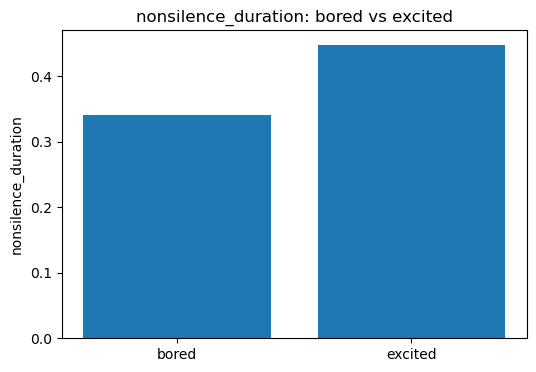

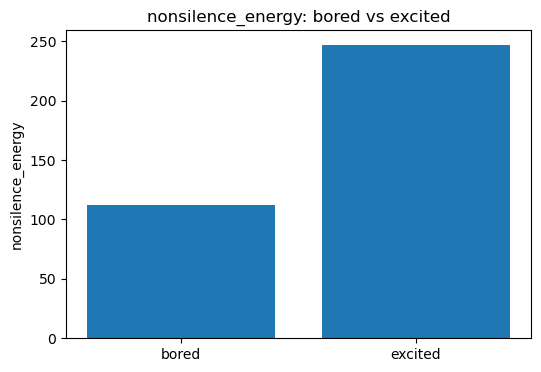

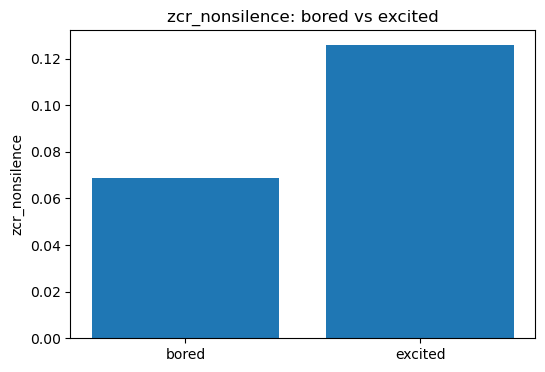

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


# Q5D: Compare bored vs excited


My_speaker = 47
datadir = "data/SpokenNumerals-main"

# 1. Your saved features file
df = pd.read_csv(f"Speaker_{My_speaker}_Audio_features.csv")

# 2.  original audio attributes file
audio_df = pd.read_csv(f"{datadir}/MLEndSND_audio_attributes_benchmark.csv")

# 3. filename and speaker columns 
file_col = [c for c in audio_df.columns if "file" in c.lower()][0]
speaker_col = [c for c in audio_df.columns if "speaker" in c.lower()][0]

# 4. Merge 
merged = pd.merge(df, audio_df, left_on="filename", right_on=file_col)

# 5. Columns
print("Columns in merged dataframe:")
print(merged.columns)

# 6. numeral/number column and intonation column
number_col = [c for c in merged.columns if any(word in c.lower() for word in ["number", "num", "digit", "numeral"])][0]
intonation_col = [c for c in merged.columns if "intonation" in c.lower()][0]

print("Number column used:", number_col)
print("Intonation column used:", intonation_col)

# 7. Filter for your speaker and numeral 1
speaker_data = merged[merged[speaker_col] == My_speaker]
num1 = speaker_data[speaker_data[number_col] == 1]

# 8. Separate bored and excited recordings
bored = num1[num1[intonation_col].str.lower() == "bored"]
excited = num1[num1[intonation_col].str.lower() == "excited"]

print("Bored files:", len(bored))
print("Excited files:", len(excited))

# 9. Compare selected features
features_to_compare = [
    "nonsilence_duration",
    "nonsilence_energy",
    "zcr_nonsilence"
]

summary = pd.DataFrame({
    "bored_mean": bored[features_to_compare].mean(),
    "bored_std": bored[features_to_compare].std(),
    "excited_mean": excited[features_to_compare].mean(),
    "excited_std": excited[features_to_compare].std()
})

print("\nComparison summary:")
print(summary)

# 10. Plot comparison
for feature in features_to_compare:
    plt.figure(figsize=(6,4))
    plt.bar(
        ["bored", "excited"],
        [bored[feature].mean(), excited[feature].mean()]
    )
    plt.title(f"{feature}: bored vs excited")
    plt.ylabel(feature)
    plt.show()

<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 6. Deeper Analysis of audio files [34 Marks]

Now that you have all the tools and skills, let's dive into deeper analysis.

As you are now familiar with the dataset - each audio file has a Numeral (e.g. 1, 2, ..., 1000000), Intonation (e.g. bored, excited, neutral, and question), and speaker number. Since you have all the audio files of one speaker, you have the flexibility to compare the features of different Numerals or different Intonations.

**Comparing two categories could go as deep as you want. You could compare only the mean of one feature, or mean and standard deviation of a selected few features, or even go further to compare more of the statistics of each feature. The important part of comparative analysis is not just to compute the different statistics but to explain the results.**


### 6.1 Compare two Numerals [10 Marks]

<br>

<div style="padding: 10px; border: 4px dashed black;">
    
**Q6A:** From all the audio files of YOUR SPEAKER, select two different Numerals (such as 1 and 2 or 100 and 1000000), and compare them using statistics. Explanation of comparative analysis is Important.

Marks for this part depend on how well you analyse and explain it. Going deeper by comparing many features is good, but it should be supported by an explaination.

</div>



### 6.2 Compare two Intonations [10 Marks]
<br>

<div style="padding: 10px; border: 4px dashed black;">

**Q6B:** From all the audio files of YOUR SPEAKER, select two different intonations (such as bored and question), and compare them using statistics. Explanation of comparative analysis is Important.

</div>




### 6.3 Compare two Speakers [14 Marks]

<br>


<div style="padding: 10px; border: 4px dashed black;">

**Q6C:** Compare your speaker with another speaker with **different nationality**. Save the comparative results as a pickle file and upload it with your submission.

Here is a modular approach to this problem: 

* Step 1: Select another speaker from the dataset who has a different nationality than your speaker. For example, if your speaker is 107, then your speaker is British. Select another speaker, who is not British. Let's call this New_Speaker 

* Step 2: Extract the features of all the audio files of this New_Speaker.

* Step 3: Compute the statistic of all the features of your speaker and this New_Speaker

* Step 4: Plot them for comparative analysis and explain in detail how different and how similar are these two speakers.

* Step 5: Save the comparative results as a pickle file. name it as 'Speaker_[Your Speaker Number]_[New_Speaker]_comparision.pkl'. for example, if your speaker is 107 and new speaker is 10, then file name should be Speaker_107_10_comparision.pkl'. Make sure to upload this file with your submission.

</div>

<br>

### Your solution: code and explanation

                     numeral_1_mean  numeral_1_std  numeral_2_mean  \
nonsilence_duration        0.399660       0.052770        0.310450   
nonsilence_energy        259.181816     140.667374      250.027214   
zcr_nonsilence             0.090670       0.031035        0.085162   

                     numeral_2_std  
nonsilence_duration       0.084000  
nonsilence_energy       216.080755  
zcr_nonsilence            0.020094  


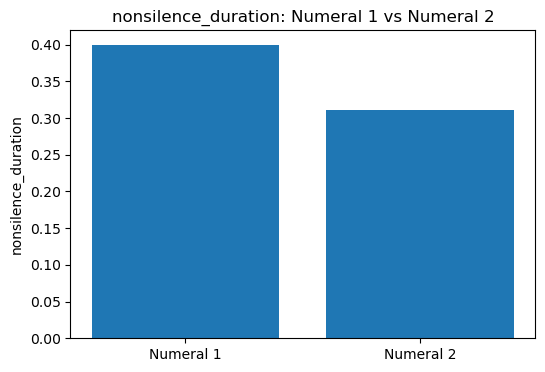

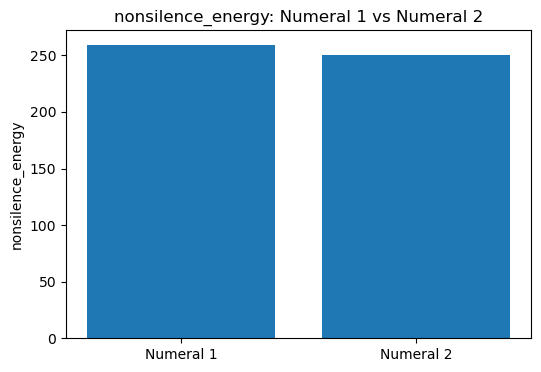

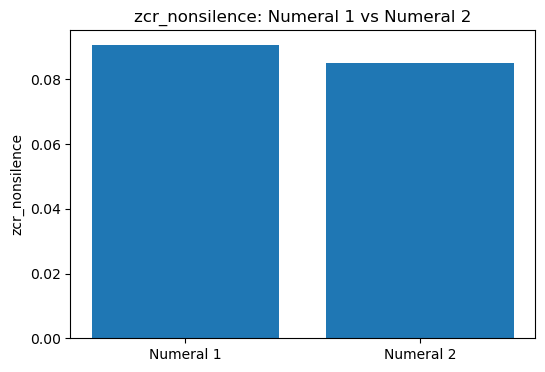

In [17]:
#Q6A


import pandas as pd
import matplotlib.pyplot as plt

My_speaker = 47
datadir = "data/SpokenNumerals-main"

features_df = pd.read_csv(f"Speaker_{My_speaker}_Audio_features.csv")
audio_df = pd.read_csv(f"{datadir}/MLEndSND_audio_attributes_benchmark.csv")

file_col = [c for c in audio_df.columns if "file" in c.lower()][0]
speaker_col = [c for c in audio_df.columns if "speaker" in c.lower()][0]
number_col = [c for c in audio_df.columns if any(w in c.lower() for w in ["num", "digit", "number", "numeral"])][0]

merged = pd.merge(features_df, audio_df, left_on="filename", right_on=file_col)

num_a = 1
num_b = 2

data_a = merged[merged[number_col] == num_a]
data_b = merged[merged[number_col] == num_b]

features = [
    "nonsilence_duration",
    "nonsilence_energy",
    "zcr_nonsilence"
]

summary_6a = pd.DataFrame({
    f"numeral_{num_a}_mean": data_a[features].mean(),
    f"numeral_{num_a}_std": data_a[features].std(),
    f"numeral_{num_b}_mean": data_b[features].mean(),
    f"numeral_{num_b}_std": data_b[features].std()
})

print(summary_6a)

for feature in features:
    plt.figure(figsize=(6,4))
    plt.bar([f"Numeral {num_a}", f"Numeral {num_b}"],
            [data_a[feature].mean(), data_b[feature].mean()])
    plt.title(f"{feature}: Numeral {num_a} vs Numeral {num_b}")
    plt.ylabel(feature)
    plt.show()



                     bored_mean  bored_std  excited_mean  excited_std
nonsilence_duration    0.236238   0.084966      0.389712     0.077616
nonsilence_energy     50.293690  39.256690    171.217851    56.597710
zcr_nonsilence         0.159283   0.117682      0.198268     0.103049


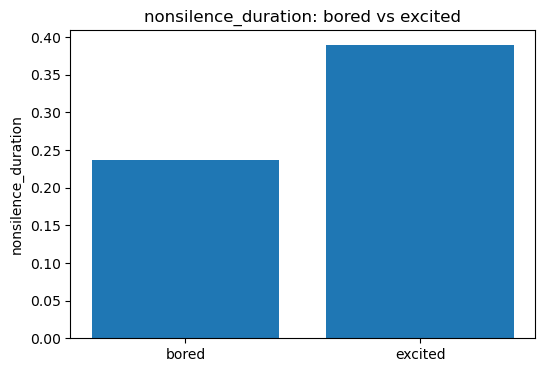

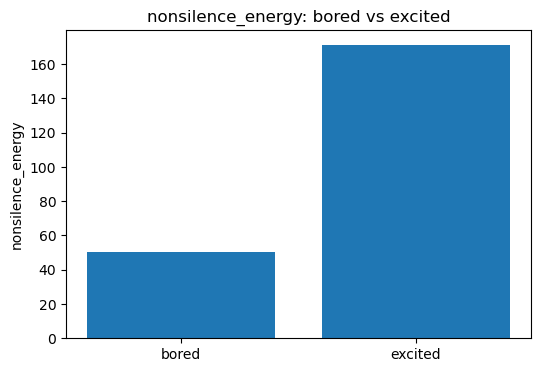

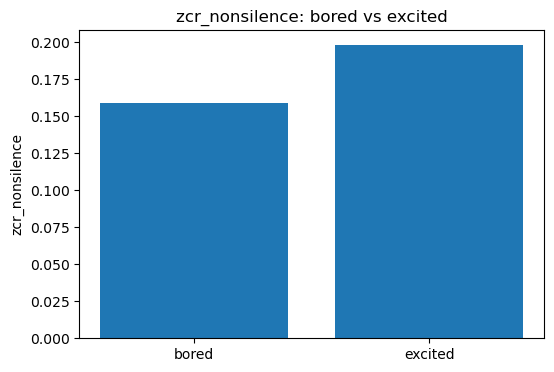

In [18]:
#Q6B

intonation_col = [c for c in merged.columns if "intonation" in c.lower()][0]

inton_a = "bored"
inton_b = "excited"

data_a = merged[merged[intonation_col].str.lower() == inton_a]
data_b = merged[merged[intonation_col].str.lower() == inton_b]

summary_6b = pd.DataFrame({
    f"{inton_a}_mean": data_a[features].mean(),
    f"{inton_a}_std": data_a[features].std(),
    f"{inton_b}_mean": data_b[features].mean(),
    f"{inton_b}_std": data_b[features].std()
})

print(summary_6b)

for feature in features:
    plt.figure(figsize=(6,4))
    plt.bar([inton_a, inton_b],
            [data_a[feature].mean(), data_b[feature].mean()])
    plt.title(f"{feature}: {inton_a} vs {inton_b}")
    plt.ylabel(feature)
    plt.show()



Speaker A files: 206
Speaker B files: 219

Comparison:
                     speaker_47_mean  speaker_47_std  speaker_49_mean  \
silence_duration            0.794777        0.205503         0.900510   
nonsilence_duration         0.397866        0.141461         0.268269   
silence_energy              0.526920        0.168388         0.456407   
nonsilence_energy         253.489961      182.700271       261.287280   
mean_pos                    0.051559        0.017957         0.058413   
std_pos                     0.084563        0.029175         0.098047   
mean_neg                   -0.047855        0.018583        -0.046938   
std_neg                     0.082107        0.029386         0.085136   
zcr_silence                 0.175393        0.061434         0.144110   
zcr_nonsilence              0.158775        0.098339         0.157697   

                     speaker_49_std  
silence_duration           0.182151  
nonsilence_duration        0.111338  
silence_energy             

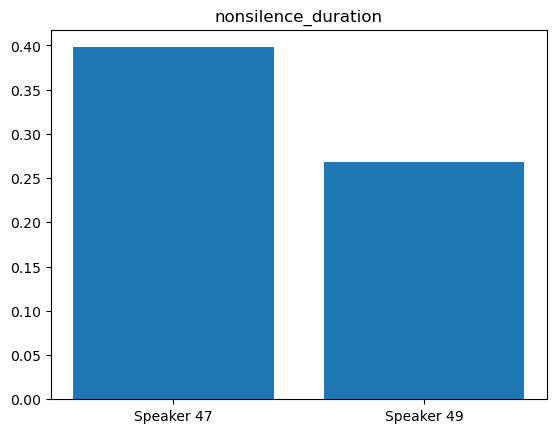

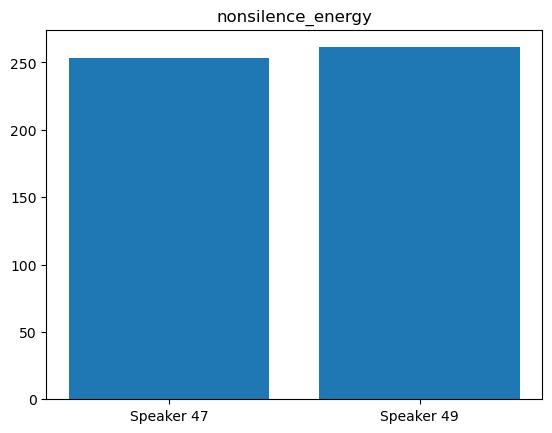

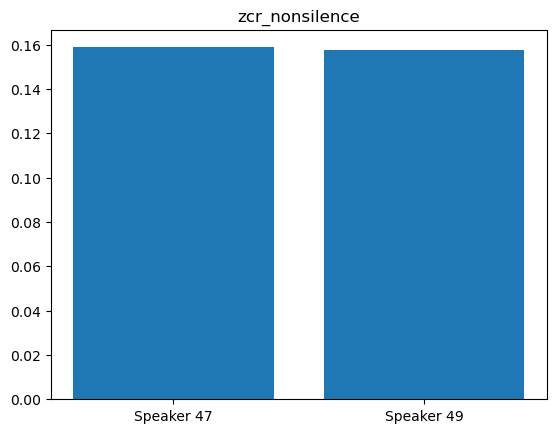

Saved: Speaker_47_49_comparison.pkl


In [20]:
#Q6C

import numpy as np
import pandas as pd
from scipy.io import wavfile
import os
import pickle
import matplotlib.pyplot as plt

#1 new speaker

datadir = "data/SpokenNumerals-main"
audio_csv = f"{datadir}/MLEndSND_audio_attributes_benchmark.csv"

speaker_A = 47
speaker_B = 49   # second speaker

audio_df = pd.read_csv(audio_csv)

# auto-detect columns
file_col = [c for c in audio_df.columns if "file" in c.lower()][0]
speaker_col = [c for c in audio_df.columns if "speaker" in c.lower()][0]

#2. Functions

def load_audio(filename):
    path = os.path.join(datadir, "MLEndSND_audiofiles", filename)
    fs, x = wavfile.read(path)
    x = x / (2**15)
    if len(x.shape) > 1:
        x = x[:, 0]
    return fs, x

def detect_silence(x, threshold=0.02):
    x_abs = np.abs(x)
    silence_idx = np.where(x_abs < threshold)[0]
    nonsilence_idx = np.where(x_abs >= threshold)[0]
    return silence_idx, nonsilence_idx

def extract_features(file_list):
    data = []
    for file in file_list:
        fs, x = load_audio(file)
        silence_idx, nonsilence_idx = detect_silence(x)

        sil_dur = len(silence_idx)/fs
        nonsil_dur = len(nonsilence_idx)/fs

        sil_energy = np.sum(x[silence_idx]**2)
        nonsil_energy = np.sum(x[nonsilence_idx]**2)

        pos = x[x > 0]
        neg = x[x < 0]

        mean_pos = np.mean(pos) if len(pos) > 0 else 0
        std_pos = np.std(pos) if len(pos) > 0 else 0
        mean_neg = np.mean(neg) if len(neg) > 0 else 0
        std_neg = np.std(neg) if len(neg) > 0 else 0

        def zcr(sig):
            if len(sig) == 0:
                return 0
            return np.sum(np.diff(np.sign(sig)) != 0) / len(sig)

        zcr_sil = zcr(x[silence_idx])
        zcr_nonsil = zcr(x[nonsilence_idx])

        data.append([
            sil_dur, nonsil_dur,
            sil_energy, nonsil_energy,
            mean_pos, std_pos,
            mean_neg, std_neg,
            zcr_sil, zcr_nonsil
        ])

    cols = [
        "silence_duration","nonsilence_duration",
        "silence_energy","nonsilence_energy",
        "mean_pos","std_pos",
        "mean_neg","std_neg",
        "zcr_silence","zcr_nonsilence"
    ]

    return pd.DataFrame(data, columns=cols)

#3 Get files for each speaker

files_A = audio_df[audio_df[speaker_col] == speaker_A][file_col].values
files_B = audio_df[audio_df[speaker_col] == speaker_B][file_col].values

print("Speaker A files:", len(files_A))
print("Speaker B files:", len(files_B))


#4 Extract features

df_A = extract_features(files_A)
df_B = extract_features(files_B)

#5 Compare statistics

features = df_A.columns

comparison = pd.DataFrame({
    "speaker_47_mean": df_A.mean(),
    "speaker_47_std": df_A.std(),
    "speaker_49_mean": df_B.mean(),
    "speaker_49_std": df_B.std()
})

print("\nComparison:")
print(comparison)

#6 Plot comparison

for feature in ["nonsilence_duration","nonsilence_energy","zcr_nonsilence"]:
    plt.figure()
    plt.bar(["Speaker 47","Speaker 49"],
            [df_A[feature].mean(), df_B[feature].mean()])
    plt.title(feature)
    plt.show()

#7 Save pickle file

filename = f"Speaker_{speaker_A}_{speaker_B}_comparison.pkl"

with open(filename, "wb") as f:
    pickle.dump(comparison, f)

print("Saved:", filename)



<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 7. Find similar audio files [10 Marks]

Now that you have created all the required functions to read audio files and extract features (10 features), and you have done many of the comparative analysis, you are ready to use all that to find similar audio files. 

This is one of the fundamentals of automated systems (intelligent systems) that are used in the field of audio and speech. Some examples are Speaker Identification, Music Recognition, and Music Information retrieval.


In this section, you will write a function to identify similar audio files from the given dataset.

<div style="padding: 10px; border: 4px dashed black;">

**Q7A:** Write a function that takes a filename (such as 00003.wav) and returns 10 audio files that are similar to this. Recall Assignment 1, for similarity, we used Euclidean Distance, we will do the same here.

Here is a modular approach to this problem: 


* Step 1: Extract all the 10 features of all the audio files in `MLEndSND_audiofiles` folder, select 5 features related to non-silience part of audio and save them along with the filename in a CSV file. Name it as `Audio_Features_All.csv`

* Step 2: Write a function that takes two filenames and 
  * Extract 5 features from of Audio_Features_All.csv for both filenames
  * Scale them and compute Euclidean Distance between them (Recall assignment 1 for scaling and normalisation)
  * Return Euclidean Distance
 
  For example, given two file names, file1='00003.wav' and file2 = '06801.wav', your function should return a single float-type number, as Euclidean Distance between file1 and file2.

* Step 3: Write a function that takes one filename and computes the Euclidean Distance of this audio file to all the other audio files, including itself. Return 10 filenames of audio files that are closest to the given file. One of the names would be itself.

  For example, given one file name file1 = '00110.wav' your function should return a list of 10 filenames, one of which should be '00110.wav'


**Q7B:** Find closest 10 audio files to '00003.wav', plot all of them with audio player. Play them and see if they are really similar.


**Some of the supporting code lines are given below.**

</div>

In [17]:
# Step 1

import numpy as np
import pandas as pd
import os
from scipy.io import wavfile
import warnings
from scipy.io.wavfile import WavFileWarning

warnings.simplefilter("ignore", WavFileWarning)


datadir = "data/SpokenNumerals-main"
audio_dir = datadir + "/MLEndSND_audiofiles"

# get all filenames

filenames = sorted([f for f in os.listdir(audio_dir) if f.endswith(".wav")])

def read_audio_file(filename):
    path = os.path.join(audio_dir, filename)
    fs, x = wavfile.read(path)
    x = x / (2**15)

    if len(x.shape) > 1:
        x = x[:, 0]

    return fs, x

def get_ten_features(x, fs):
    threshold = 0.02

    silence_idx = np.where(np.abs(x) < threshold)[0]
    nonsilence_idx = np.where(np.abs(x) >= threshold)[0]

    sil_dur = len(silence_idx) / fs
    nonsil_dur = len(nonsilence_idx) / fs

    sil_energy = np.sum(x[silence_idx]**2)
    nonsil_energy = np.sum(x[nonsilence_idx]**2)

    pos = x[x > 0]
    neg = x[x < 0]

    mean_pos = np.mean(pos) if len(pos) > 0 else 0
    std_pos = np.std(pos) if len(pos) > 0 else 0
    mean_neg = np.mean(neg) if len(neg) > 0 else 0
    std_neg = np.std(neg) if len(neg) > 0 else 0

    def zcr(sig):
        if len(sig) == 0:
            return 0
        return np.sum(np.diff(np.sign(sig)) != 0) / len(sig)

    zcr_sil = zcr(x[silence_idx])
    zcr_nonsil = zcr(x[nonsilence_idx])

    return [
        sil_dur, nonsil_dur,
        sil_energy, nonsil_energy,
        mean_pos, std_pos,
        mean_neg, std_neg,
        zcr_sil, zcr_nonsil
    ]

print("Feature extraction complete!")
print("Rows created:", len(Audio_Features))

# Complete the code or re-write yourself

Audio_Features = []

# Complete the code 
for filename in filenames:
    
    fs, x = read_audio_file(filename)  
    
    ten_features = get_ten_features(x, fs)


    five_features = [
        ten_features[1],  # nonsilence duration
        ten_features[3],  # nonsilence energy
        ten_features[4],  # mean positive
        ten_features[5],  # std positive
        ten_features[9]   # zcr non-silence
    ]
    
    fname_feature = [filename] + list(five_features)
    Audio_Features.append(fname_feature)

    print("Feature extraction complete!")
print("Rows created:", len(Audio_Features))

#save CSV

os.makedirs("./data", exist_ok=True)

D = pd.DataFrame(Audio_Features, columns=["filename", "f1", "f2", "f3", "f4", "f5"])

save_path = "./data/Audio_Features_All.csv"
D.to_csv(save_path, index=False)

print("\nCSV saved successfully!")
print("Location:", os.path.abspath(save_path))
print("Shape:", D.shape)
print(D.head())

    

Feature extraction complete!
Rows created: 32716
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction complete!
Feature extraction comp

In [9]:
D = pd.DataFrame(Audio_Features, columns=['filename','f1','f2','f3','f4','f5'])
D.to_csv("./data/Audio_Features_All.csv", index=False)

D.head()

,filename,f1,f2,f3,f4,f5
0,00000.wav,0.365941,333.176787,0.068806,0.117819,0.071632
1,00001.wav,0.103855,2.303734,0.003801,0.008472,0.068122
2,00003.wav,0.596825,381.591502,0.055231,0.084323,0.040350
3,00004.wav,0.597914,155.274667,0.041220,0.062576,0.107327
4,00005.wav,0.058685,2.712069,0.006801,0.013618,0.180835


In [45]:
# Step 2

import pandas as pd
import numpy as np

def closeness_audiofiles(file1, file2):
    D = pd.read_csv("./data/Audio_Features_All.csv")

    feature_cols = ["f1", "f2", "f3", "f4", "f5"]

    # min-max scaling
    X = D[feature_cols]
    X_scaled = (X - X.min()) / (X.max() - X.min())

    v1 = X_scaled[D["filename"] == file1].values[0]
    v2 = X_scaled[D["filename"] == file2].values[0]

    euc_dist = np.sqrt(np.sum((v1 - v2) ** 2))

    return euc_dist

distance = closeness_audiofiles("00008.wav", "06802.wav")
print("Distance:", distance)
  

Distance: 0.24219356996846775


In [50]:
# Step 3

import pandas as pd
import numpy as np

# Load feature 

D = pd.read_csv("./data/Audio_Features_All.csv")

feature_cols = ["f1", "f2", "f3", "f4", "f5"]


# Scale features

X = D[feature_cols]
X_scaled = (X - X.min()) / (X.max() - X.min())

# Step 2: distance 

def closeness_audiofiles(file1, file2):
    if file1 not in list(D["filename"]):
        print(file1, "not found")
        return None

    if file2 not in list(D["filename"]):
        print(file2, "not found")
        return None

    v1 = X_scaled[D["filename"] == file1].values[0]
    v2 = X_scaled[D["filename"] == file2].values[0]

    distance = np.sqrt(np.sum((v1 - v2) ** 2))

    return distance



# Step 3: closest 10 files
def closest_10_audiofiles(filename):
    if filename not in list(D["filename"]):
        print(filename, "not found")
        print("Try one of these:", D["filename"].head(10).tolist())
        return None

    
    target = X_scaled[D["filename"] == filename].values[0]

    distances = []

    
    for i in range(len(D)):
        current = X_scaled.iloc[i].values
        dist = np.sqrt(np.sum((target - current) ** 2))
        distances.append(dist)

    
    D_temp = D.copy()
    D_temp["distance"] = distances

    closest = D_temp.sort_values("distance").head(10)

    return closest[["filename", "distance"]]



# Test


test_file = D["filename"].iloc[0]


print("Test file:", test_file)


result = closest_10_audiofiles(test_file)




print(result)

Test file: 00000.wav
        filename  distance
0      00000.wav  0.000000
19706  28400.wav  0.017139
4158   06052.wav  0.019524
23162  33445.wav  0.021303
14288  20618.wav  0.022735
8961   12929.wav  0.023135
22187  32046.wav  0.023528
20925  30213.wav  0.024246
4259   06188.wav  0.026797
28913  41712.wav  0.027035


In [ ]:
Your Explanation:



Q7A: Explain your approach

1) First I used the features that were already extracted for each audio file.
These features characterise the sound, such as duration, energy and variation.
2) I extracted 5 features from the non-silence part of the audio.
This is because the useful speech signal is contained in the non-silence part.
3) I performed min-max scaling on the feature values.
This scales all values to be between 0 and 1, so that no feature is too big or too small relative to other features.
4) I wrote a function to calculate the distance between two audio files. 
We did this by using Euclidean distance, which is a way of measuring how different two sets of features are.
5) If two files have very similar features, their distance will be small.
If they are very different, the distance will be big.
6) Then I picked one audio file as reference file.
7) Calculated the distance from the ref file to every other file.
8) Sorted all the filed based on their distance values.
9) Selected 10 files with the smallest distance values.
10) Final result of 10 closest audio files.












Closest 10 files to: 00003.wav
        filename  distance
2      00003.wav  0.000000
12190  17552.wav  0.012651
398    00591.wav  0.013218
13369  19270.wav  0.019735
32538  46804.wav  0.020441
13220  19043.wav  0.022102
28926  41731.wav  0.023088
23198  33494.wav  0.025495
4322   06282.wav  0.025901
8201   11843.wav  0.026781


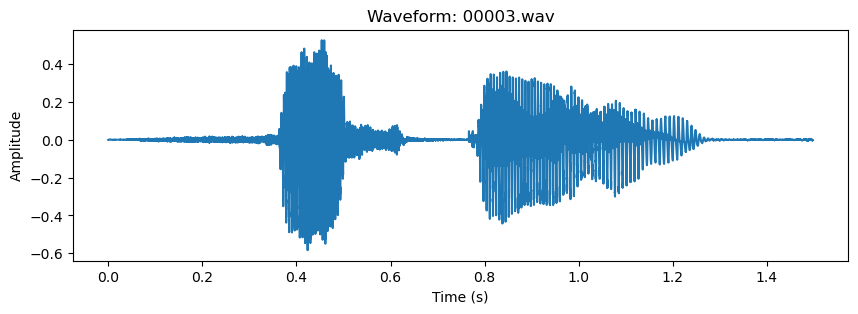

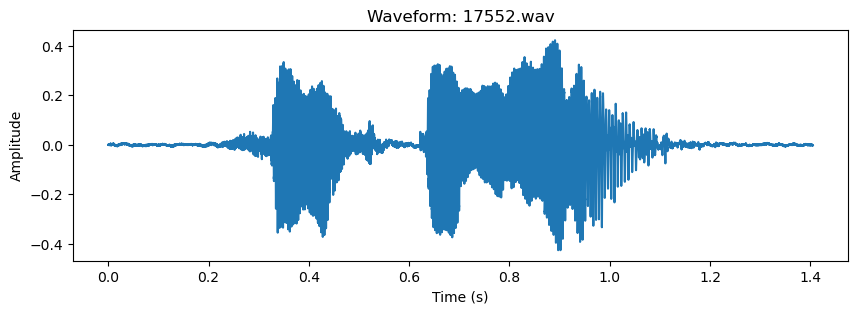

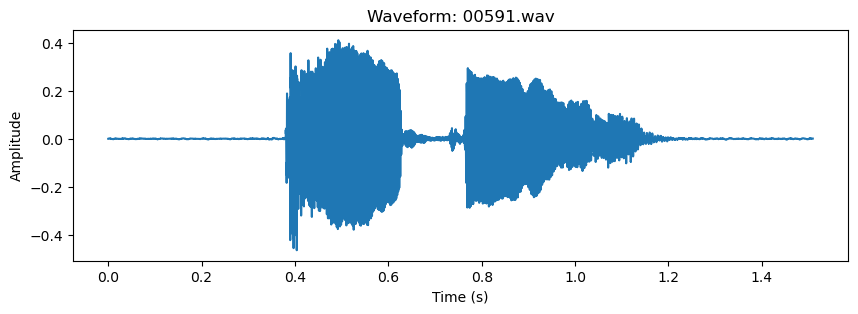

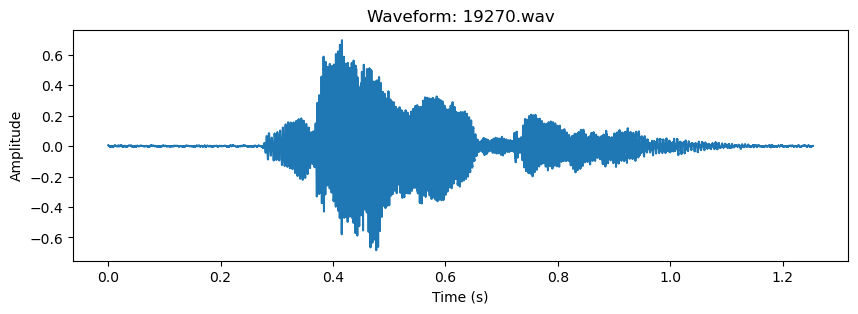

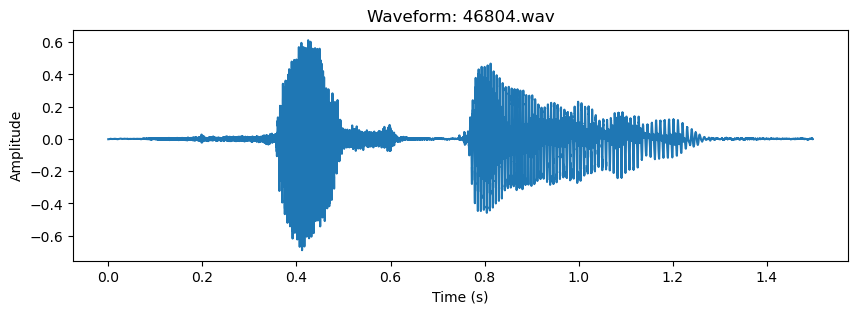

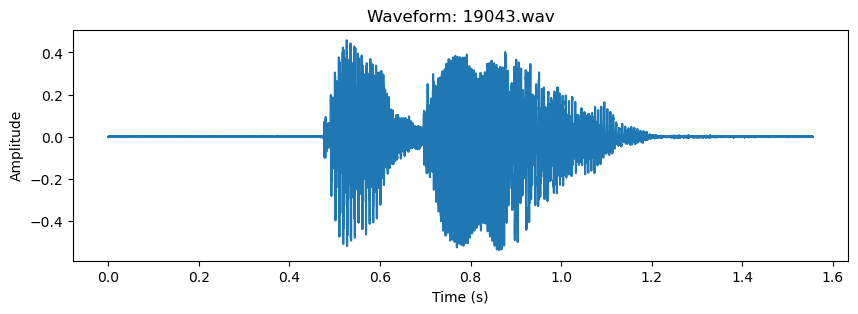

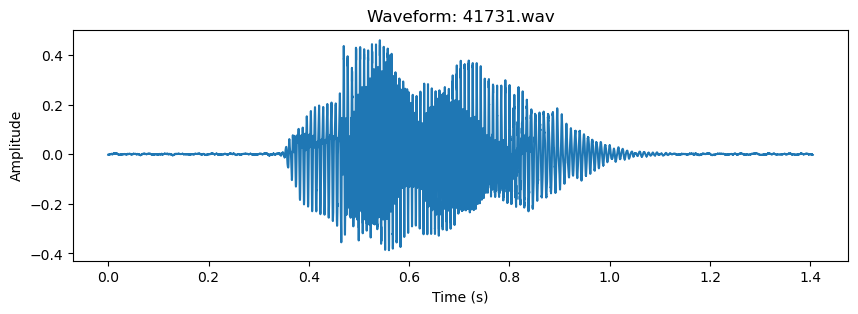

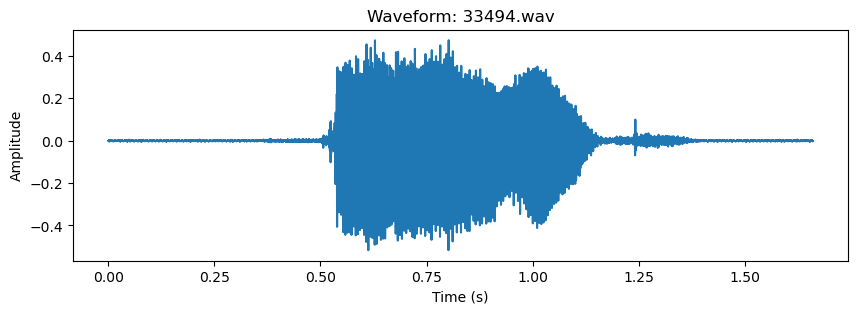

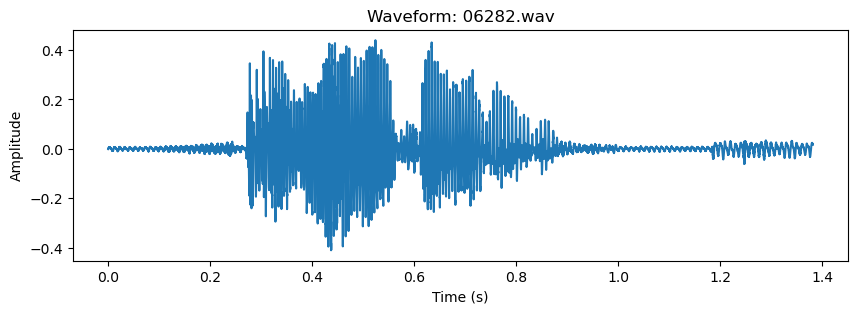

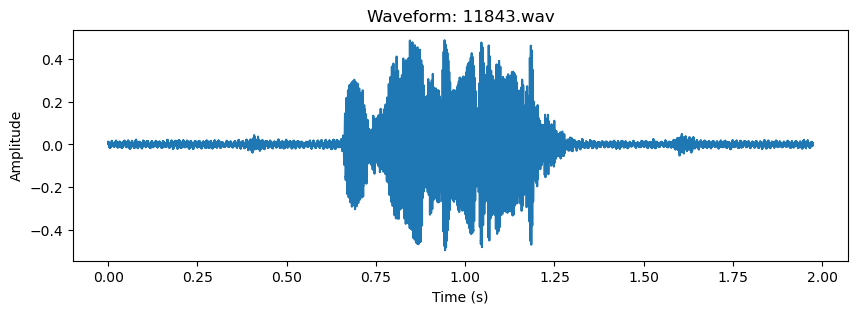

In [61]:
#Q7B

import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display
import numpy as np
import os


# Paths

datadir = "data/SpokenNumerals-main"
audio_dir = os.path.join(datadir, "MLEndSND_audiofiles")


# Choose file

test_file = "00003.wav"

# check file exists
if test_file not in list(D["filename"]):
    print("File not found. Available examples:")
    print(D["filename"].head(10).tolist())
else:

    # get closest 10 files
    result = closest_10_audiofiles(test_file)

    print("Closest 10 files to:", test_file)
    print(result)

    
# Plot + Play all 10 files
    
    for filename in result["filename"]:

        path = os.path.join(audio_dir, filename)

        # read audio
        fs, x = wavfile.read(path)

        # convert to float
        x = x / (2**15)

        # handle stereo
        if len(x.shape) > 1:
            x = x[:, 0]

        # time axis
        t = np.arange(len(x)) / fs

        # plot waveform
        plt.figure(figsize=(10,3))
        plt.plot(t, x)
        plt.title(f"Waveform: {filename}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.show()

        # audio player
        display(Audio(x, rate=fs))

<div style="padding: 3px; border: 2px solid black; background-color: gray"></div>

## 8. Submission Instructions

To tick the boxes below, double click on the segment, and edit '[ ]' to '[x]'

<div style="padding: 10px; border: 2px solid blue;">
    
Before uploading your submission to QMplus, make sure that (checklist):

* [ ] Your name and QMUL ID are added at the top of the Jupyter-notebook.
* [ ] All the figures and code are saved.
* [ ] Your solution Jupyter-notebook and result files ( CSV file from Q5.2 and pickle file from Q6.3) are in the same folder.
* [ ] Excluding data, compress them to a Zip file and rename it as [Your_Name]_[QMUL_ID]_Assignment2.zip.
* [ ] **Make sure to exclude data folder which includes all the audio files**, otherwise your submission file will be very large.
* [ ] Do not include Spoken Numerals Dataset in your zip file, we will use the original Dataset to test your code and solution.
* [ ] Upload it using the link provided on QMPlus.
* [ ] You are allowed to submit one Zip file only, which should contain your Jupyter-Notebook file and result files ( CSV file from Q5.2 and pickle file from Q6.3).
* **Deadline** to submit your assignment is **Friday (01 of May of 2026), at 17:00 (5:00PM)**.

</div>


<div style="padding: 10px; border: 2px solid black;">
    
**Academic honesty declaration**
* [ x] I declare that I have completed this assignment on my own.
      
Your Name Eric Kamalendran
</div>